# <font color=#0099CC>**Notebook 4: Backtest, Ejecución y Costes**</font>

En este notebook se ejecuta el **motor de backtesting** de la estrategia Momentum con las siguientes reglas:

- **Rebalanceo mensual** el último día hábil de cada mes, con la señal del Notebook 3 (`selected_assets.csv`).
- **Venta** de posiciones que salen de la cartera al **OPEN** del día de rebalanceo.
- **Compra** de nuevas posiciones al **CLOSE** del mismo día.
- **Comisiones**: 0,23 % sobre el valor efectivo de cada operación, con mínimo de 23 $ por orden.
- **Delistings**: si un activo deja de cotizar, se vende a precio close el último día disponible y el efectivo permanece en liquidez hasta el siguiente rebalanceo.
- Se calcula la curva de equity diaria de la estrategia y del benchmark SPY.


In [54]:
# Librerías
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Permite importar utilidades compartidas desde la raíz del proyecto
project_root = Path.cwd().resolve()
if not (project_root / 'notebook_utils.py').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from notebook_utils import configure_notebook_display, get_project_paths

# Configuración de visualización
configure_notebook_display(max_columns=None, max_rows=100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Parámetros del backtest
INITIAL_CAPITAL = 250_000.0
COMMISSION_RATE = 0.0023  # 0.23 %
MIN_COMMISSION = 23.0

BACKTEST_START = pd.Timestamp('2015-01-01')
BACKTEST_END = pd.Timestamp('2026-01-30')

# Rutas de entrada/salida centralizadas
PATHS = get_project_paths(project_root)
DATASETS_DIR = PATHS.datasets
OUTPUTS_DIR = PATHS.outputs

> <u>Nota</u>: Este notebook usa componentes compartidos de `notebook_utils.py` para centralizar configuración y rutas del proyecto, reforzando modularidad y reutilización. Se ha priorizado claridad visual, nombres explícitos y comentarios orientados a explicar lógica de negocio.

## <font color=#0099CC>**1. CARGA DE DATOS**</font>

Se cargan el histórico S&P 500, el benchmark SPY y las selecciones mensuales del Notebook 3 (`selected_assets.csv`).

In [55]:
# Carga de datos necesarios (diarios)

# Historia diaria S&P 500
sp500_hist = pd.read_parquet(DATASETS_DIR / 'sp500_history_deduplicated.parquet')  # histórico deduplicado (N2)
sp500_hist['date'] = pd.to_datetime(sp500_hist['date']) # Aseguramos que la columna 'date' es de tipo datetime
sp500_hist = sp500_hist.set_index('date').sort_index() # Establecemos 'date' como índice y ordenamos por fecha

# Benchmark SPY: siempre ajustado (generado en N1 con auto_adjust=True)
spy = pd.read_parquet(DATASETS_DIR / 'spy_benchmark.parquet')
spy.index = pd.to_datetime(spy.index)

# Soporta tanto columnas simples como MultiIndex de yfinance
if isinstance(spy.columns, pd.MultiIndex):
    if 'Close' not in spy.columns.get_level_values(0):
        raise ValueError("El parquet de SPY no contiene columna 'Close' ajustada.")
    spy_close = spy.xs('Close', axis=1, level=0)
    if isinstance(spy_close, pd.Series):
        spy_close = spy_close.to_frame(name='SPY')
    else:
        spy_close = spy_close.iloc[:, [0]].copy()
        spy_close.columns = ['SPY']
else:
    if 'Close' in spy.columns:
        spy_close = spy[['Close']].rename(columns={'Close': 'SPY'})
    else:
        spy_close = spy.iloc[:, [0]].copy()
        spy_close.columns = ['SPY']

spy_close.index.name = 'date'  # Índice de fechas para alinear con el backtest

# Selecciones mensuales de la estrategia (Notebook 3)
selected = pd.read_csv(OUTPUTS_DIR / 'selected_assets.csv', parse_dates=['rebalance_date'])

print('> Datos cargados:')
print(f"  - sp500_hist: {sp500_hist.shape}")
print(f"  - spy_close: {spy_close.shape}")
print(f"  - selected: {selected.shape}")

# Comprobación: nº de activos por rebalanceo (debe ser 20 en todos los meses)
counts_sel = selected.groupby('rebalance_date').size()
print(f"  - Activos por rebalanceo: min={counts_sel.min()}, max={counts_sel.max()}")
if (counts_sel != 20).any():
    print(f"  - Atención: hay {(counts_sel != 20).sum()} fechas con distinto de 20 activos.")
else:
    print("  - Todas las fechas de rebalanceo tienen 20 activos.")

> Datos cargados:
  - sp500_hist: (7043936, 13)
  - spy_close: (6588, 1)
  - selected: (2640, 5)
  - Activos por rebalanceo: min=20, max=20
  - Todas las fechas de rebalanceo tienen 20 activos.


## <font color=#0099CC>**2. TABLAS PIVOT DE PRECIOS DIARIOS**</font>

Se construyen las matrices de precios **open** y **close** por fecha y símbolo, necesarias para aplicar las reglas de ejecución (venta al OPEN, compra al CLOSE) y para la valoración diaria de la cartera.

In [56]:
# Tablas pivot diarias de precios open/close por símbolo

prices_open = sp500_hist.pivot_table(
    index=sp500_hist.index,
    columns='symbol',
    values='open',
    aggfunc='last'
)

prices_close = sp500_hist.pivot_table(
    index=sp500_hist.index,
    columns='symbol',
    values='close',
    aggfunc='last'
)

prices_open.index = pd.to_datetime(prices_open.index)
prices_close.index = pd.to_datetime(prices_close.index)

prices_open = prices_open.sort_index()
prices_close = prices_close.sort_index()

# Pivot de in_sp500 para vender al día que salga de mercado o del índice
in_sp500_daily = sp500_hist.pivot_table(
    index=sp500_hist.index,
    columns='symbol',
    values='in_sp500',
    aggfunc='last'
)
in_sp500_daily.index = pd.to_datetime(in_sp500_daily.index)
in_sp500_daily = in_sp500_daily.sort_index().reindex(prices_close.index).fillna(0)

print('> Tablas pivot de precios diarias creadas')
print(f"\nprices_open: {prices_open.shape}")
display(prices_open.head())
print(f"prices_close: {prices_close.shape}")
display(prices_close.head())

> Tablas pivot de precios diarias creadas

prices_open: (9087, 1234)


symbol,A,AABA-201910,AAL,AAMRQ-201312,AAP,AAPL,AAV-199901,ABBV,ABI-200811,ABKFQ-201304,ABMD-202212,ABNB,ABS-200606,ABT,ACAS-201701,ACGL,ACKH-200712,ACN,ACS-201002,ACV-201105,ACY-199411,ADBE,ADCT-201012,ADI,ADM,ADP,ADSK,ADT-201604,AEE,AEP,AES,AET-201811,AFL,AFS-200011,AGC-200108,AGN-201503,AHM-199810,AIG,AIT-199910,AIV,AIZ,AJG,AKAM,AKS-202003,AL-200711,ALB,ALGN,ALK,ALL,ALLE,ALTR-201512,ALXN-202107,AM-201308,AMAT,AMCC-201701,AMCR,AMD,AME,AMG,AMGN,AMH-199709,AMP,AMT,AMTM,AMX-199311,AMZN,AN-199812,ANDV-201809,ANDW-200712,ANET,ANF,ANRZQ-201607,ANSS-202507,ANV-199904,AON,AOS,APA,APC-201908,APCC-200702,APD,APH,APO,APOL-201702,APP,APTV,AR-199911,ARC-200004,ARE,ARES,ARG-201605,AS-199909,ASC-199906,ASH,ASN-200710,ASND-199906,ASO-200611,AT-200711,ATGE,ATI-199906,ATO,ATVI-202310,AV-200710,AVB,AVGO,AVP-202001,AVY,AW-200812,AWE-200410,AWK,AXON,AXP,AYE-201102,AYI,AZA-200106,AZO,B,BA,BAC,BALL,BAX,BAY-199808,BBBYQ-202309,BBI-199801,BBWI,BBY,BC,BCO,BCR-201712,BDK-201003,BDX,BEAM-201404,BEN,BEV-200603,BF.B,BFH,BFI-199907,BFO-200010,BG,BGEN-200311,BGGSQ-202101,BHF,BHMSQ-200401,BIGGQ,BIO,BJS-201004,BK,BKB-199909,BKNG,BKR,BLDR,BLK,BLS-200612,BLY-199612,BMC-201309,BMET-200709,BMG-200101,BMS-201906,BMY,BN-199503,BNI-201002,BNL-199806,BNSSA-201206,BOAT-199701,BOL-200710,BR-200603,BRCM-201601,BRK.B,BRL-200812,BRNO-199508,BRO,BSC-200805,BSET,BSX,BT-199906,BTUUQ-201704,BUD-200811,BV-199409,BVSN-202005,BWA,BWY-199510,BX,BXLT-201606,BXP,C,CA-201811,CAG,CAH,CAL,CAM-201604,CAR,CARR,CAT,CB-201601,CBB-199801,CBE-201211,CBH-200803,CBL-199010,CBOE,CBRE,CBS-200005,CBSS-200709,CCB-199602,CCEP,CCI,CCK,CCL,CCTYQ-201109,CCU-200807,CDNS,CDW,CE-200402,CEG,CELG-201911,CEN-200711,CEPH-201110,CERN-202206,CF,CFC-200806,CFG,CFL-199804,CFN-201503,CG-200011,CGP-200101,CHA-200006,CHD,CHIR-200604,CHKAQ-202102,CHRS-201206,CHRW,CHTR,CI,CIC-199505,CIEN,CIN-200603,CINF,CITGQ-200912,CKL-199505,CL,CLF,CLX,CMA,CMB-199603,CMCSA,CMCSK-201512,CME,CMG,CMI,CMS,CMVT-201302,CMX-200703,CNA,CNC,CNCEQ-200309,CNG-200001,CNP,CNW-201510,CNX,CNXT-201104,COC-200208,COF,COIN,COL-201811,COMS-201004,COO,COP,COR,COST,COTY,COV-201501,CPAY,CPB,CPGX-201606,CPNLQ-200802,CPPRQ-202102,CPQ-200205,CPRI,CPRT,CPT,CPWR-201412,CRH,CRL,CRM,CRR-199706,CRWD,CSCO,CSE-199911,CSGP,CSR-200006,CSRA-201804,CSX,CTAS,CTB-202106,CTCO-199110,CTLT-202412,CTRA,CTSH,CTVA,CTX-200908,CTXS-202209,CUE-199309,CVC-201606,CVG-201810,CVGQE-200412,CVH-201305,CVN-199112,CVNA,CVS,CVX,CXO-202101,CXT,CYM-199912,CYR-199606,CZR,D,DAL,DASH,DAY,DCNAQ-200801,DD,DDOG,DDS,DE,DEC-199806,DECK,DELL-201310,DFODQ-202106,DFS-202505,DG,DGN-199910,DGX,DHI,DHR,DI-199809,DIGI-199809,DINO,DIS,DISCK-202204,DISH-202312,DJ-200712,DLR,DLTR,DLX,DNB-201902,DNRCQ-202009,DOC,DOFSQ-202104,DOV,DOW-201708,DPHIQ-200910,DPZ,DRE-202209,DRI,DTE,DTV-201507,DUK,DVA,DVN,DWD-199705,DXC,DXCM,DYHGQ-200012,DYN-201804,E-199504,EA,EBAY,EC-200606,ECH-199807,ECL,ECO-200301,ED,EDS-200808,EFU-200011,EFX,EG,EHC,EIX,EKDKQ-201309,EL,ELV,EMC-201609,EME,EMN,EMR,ENDPQ-202405,ENPH,ENRNQ-200411,ENS-199708,EOG,EOP-200702,EP-201205,EPAM,EQ-200906,EQIX,EQR,EQT,ERIE,ES,ESRX-201812,ESS,ESY-199505,ETFC-202010,ETN,ETR,ETS-200603,ETSY,EVHC-201810,EVRG,EW,EXC,EXE,EXPD,EXPE,EXR,F,FANG,FAST,FBF-200403,FBIN,FBO-199603,FCN-199810,FCX,FDC-200709,FDO-201507,FDS,FDX,FE,FFB-199512,FFIV,FG-199804,FHI,FHN,FICO,FIS,FISV,FITB,FIX,FJ-200011,FJCC-200809,FL-202509,FLIR-202105,FLMIQ-200408,FLR,FLS,FLTWQ-200907,FMC,FMCC,FMY-199905,FNB-199511,FNMA,FOSL,FOXA,FPC-200011,FRCB,FRM-199612,FRO-199909,FRT,FRX-201406,FSH-200611,FSL.B-200612,FSLR,FTI,FTL-200004,FTNT,FTRCQ-202104,FTV,FWLT-201412,G-200509,GAP,GAPTQ-201203,GAS-201606,GBLXQ-200312,GCO,GD,GDDY,GDT-200604,GDW-200609,GE,GEB-199408,GEHC,GEN,GENZ-201104,GEV,GFS.A-199810,GGP-201808,GHC-199308,GIC-200001,GIDL-199709,GILD,GIS,GL,GLD-199705,GLK-200507,GLW,GM,GMCR-201603,GME,GNE-199906,GNN-199006,GNRC,GNT-199806,GNW,GOOGL,GOSHA-200507,GP-200512,GPC,GPN,GPU-200111,GQ-199404,GR-201207,GRA-202109,GRMN,GRN-199812,GS,GSX-199810,GT,GTE-200006,GTW-200710,GWF-199707,GWOW-201009,GWW,H-20

prices_close: (9087, 1234)


symbol,A,AABA-201910,AAL,AAMRQ-201312,AAP,AAPL,AAV-199901,ABBV,ABI-200811,ABKFQ-201304,ABMD-202212,ABNB,ABS-200606,ABT,ACAS-201701,ACGL,ACKH-200712,ACN,ACS-201002,ACV-201105,ACY-199411,ADBE,ADCT-201012,ADI,ADM,ADP,ADSK,ADT-201604,AEE,AEP,AES,AET-201811,AFL,AFS-200011,AGC-200108,AGN-201503,AHM-199810,AIG,AIT-199910,AIV,AIZ,AJG,AKAM,AKS-202003,AL-200711,ALB,ALGN,ALK,ALL,ALLE,ALTR-201512,ALXN-202107,AM-201308,AMAT,AMCC-201701,AMCR,AMD,AME,AMG,AMGN,AMH-199709,AMP,AMT,AMTM,AMX-199311,AMZN,AN-199812,ANDV-201809,ANDW-200712,ANET,ANF,ANRZQ-201607,ANSS-202507,ANV-199904,AON,AOS,APA,APC-201908,APCC-200702,APD,APH,APO,APOL-201702,APP,APTV,AR-199911,ARC-200004,ARE,ARES,ARG-201605,AS-199909,ASC-199906,ASH,ASN-200710,ASND-199906,ASO-200611,AT-200711,ATGE,ATI-199906,ATO,ATVI-202310,AV-200710,AVB,AVGO,AVP-202001,AVY,AW-200812,AWE-200410,AWK,AXON,AXP,AYE-201102,AYI,AZA-200106,AZO,B,BA,BAC,BALL,BAX,BAY-199808,BBBYQ-202309,BBI-199801,BBWI,BBY,BC,BCO,BCR-201712,BDK-201003,BDX,BEAM-201404,BEN,BEV-200603,BF.B,BFH,BFI-199907,BFO-200010,BG,BGEN-200311,BGGSQ-202101,BHF,BHMSQ-200401,BIGGQ,BIO,BJS-201004,BK,BKB-199909,BKNG,BKR,BLDR,BLK,BLS-200612,BLY-199612,BMC-201309,BMET-200709,BMG-200101,BMS-201906,BMY,BN-199503,BNI-201002,BNL-199806,BNSSA-201206,BOAT-199701,BOL-200710,BR-200603,BRCM-201601,BRK.B,BRL-200812,BRNO-199508,BRO,BSC-200805,BSET,BSX,BT-199906,BTUUQ-201704,BUD-200811,BV-199409,BVSN-202005,BWA,BWY-199510,BX,BXLT-201606,BXP,C,CA-201811,CAG,CAH,CAL,CAM-201604,CAR,CARR,CAT,CB-201601,CBB-199801,CBE-201211,CBH-200803,CBL-199010,CBOE,CBRE,CBS-200005,CBSS-200709,CCB-199602,CCEP,CCI,CCK,CCL,CCTYQ-201109,CCU-200807,CDNS,CDW,CE-200402,CEG,CELG-201911,CEN-200711,CEPH-201110,CERN-202206,CF,CFC-200806,CFG,CFL-199804,CFN-201503,CG-200011,CGP-200101,CHA-200006,CHD,CHIR-200604,CHKAQ-202102,CHRS-201206,CHRW,CHTR,CI,CIC-199505,CIEN,CIN-200603,CINF,CITGQ-200912,CKL-199505,CL,CLF,CLX,CMA,CMB-199603,CMCSA,CMCSK-201512,CME,CMG,CMI,CMS,CMVT-201302,CMX-200703,CNA,CNC,CNCEQ-200309,CNG-200001,CNP,CNW-201510,CNX,CNXT-201104,COC-200208,COF,COIN,COL-201811,COMS-201004,COO,COP,COR,COST,COTY,COV-201501,CPAY,CPB,CPGX-201606,CPNLQ-200802,CPPRQ-202102,CPQ-200205,CPRI,CPRT,CPT,CPWR-201412,CRH,CRL,CRM,CRR-199706,CRWD,CSCO,CSE-199911,CSGP,CSR-200006,CSRA-201804,CSX,CTAS,CTB-202106,CTCO-199110,CTLT-202412,CTRA,CTSH,CTVA,CTX-200908,CTXS-202209,CUE-199309,CVC-201606,CVG-201810,CVGQE-200412,CVH-201305,CVN-199112,CVNA,CVS,CVX,CXO-202101,CXT,CYM-199912,CYR-199606,CZR,D,DAL,DASH,DAY,DCNAQ-200801,DD,DDOG,DDS,DE,DEC-199806,DECK,DELL-201310,DFODQ-202106,DFS-202505,DG,DGN-199910,DGX,DHI,DHR,DI-199809,DIGI-199809,DINO,DIS,DISCK-202204,DISH-202312,DJ-200712,DLR,DLTR,DLX,DNB-201902,DNRCQ-202009,DOC,DOFSQ-202104,DOV,DOW-201708,DPHIQ-200910,DPZ,DRE-202209,DRI,DTE,DTV-201507,DUK,DVA,DVN,DWD-199705,DXC,DXCM,DYHGQ-200012,DYN-201804,E-199504,EA,EBAY,EC-200606,ECH-199807,ECL,ECO-200301,ED,EDS-200808,EFU-200011,EFX,EG,EHC,EIX,EKDKQ-201309,EL,ELV,EMC-201609,EME,EMN,EMR,ENDPQ-202405,ENPH,ENRNQ-200411,ENS-199708,EOG,EOP-200702,EP-201205,EPAM,EQ-200906,EQIX,EQR,EQT,ERIE,ES,ESRX-201812,ESS,ESY-199505,ETFC-202010,ETN,ETR,ETS-200603,ETSY,EVHC-201810,EVRG,EW,EXC,EXE,EXPD,EXPE,EXR,F,FANG,FAST,FBF-200403,FBIN,FBO-199603,FCN-199810,FCX,FDC-200709,FDO-201507,FDS,FDX,FE,FFB-199512,FFIV,FG-199804,FHI,FHN,FICO,FIS,FISV,FITB,FIX,FJ-200011,FJCC-200809,FL-202509,FLIR-202105,FLMIQ-200408,FLR,FLS,FLTWQ-200907,FMC,FMCC,FMY-199905,FNB-199511,FNMA,FOSL,FOXA,FPC-200011,FRCB,FRM-199612,FRO-199909,FRT,FRX-201406,FSH-200611,FSL.B-200612,FSLR,FTI,FTL-200004,FTNT,FTRCQ-202104,FTV,FWLT-201412,G-200509,GAP,GAPTQ-201203,GAS-201606,GBLXQ-200312,GCO,GD,GDDY,GDT-200604,GDW-200609,GE,GEB-199408,GEHC,GEN,GENZ-201104,GEV,GFS.A-199810,GGP-201808,GHC-199308,GIC-200001,GIDL-199709,GILD,GIS,GL,GLD-199705,GLK-200507,GLW,GM,GMCR-201603,GME,GNE-199906,GNN-199006,GNRC,GNT-199806,GNW,GOOGL,GOSHA-200507,GP-200512,GPC,GPN,GPU-200111,GQ-199404,GR-201207,GRA-202109,GRMN,GRN-199812,GS,GSX-199810,GT,GTE-200006,GTW-200710,GWF-199707,GWOW-201009,GWW,H-20

## <font color=#0099CC>**3. FECHAS DE REBALANCEO Y DELISTINGS**</font>

Se obtienen las fechas de rebalanceo (último día hábil de cada mes) y, por cada símbolo, la última fecha con precio disponible para detectar salidas de cotización y vender a close ese día.

In [57]:
# Fechas de rebalanceo y últimas fechas de cotización por activo

# Fechas de rebalanceo (mensuales) a partir del CSV de seleccionados
rebalance_dates_from_csv = (
    selected['rebalance_date']
    .drop_duplicates()
    .sort_values()
    .tolist()
)

# Mapear cada fecha del CSV al día hábil real en prices_open (evita perder fechas por diferencia de tipo/hora)
prices_index = prices_open.index
rebalance_dates = []
for d in rebalance_dates_from_csv:
    dn = pd.Timestamp(d).normalize()
    if dn in prices_index:
        rebalance_dates.append(dn)
    else:
        prior = prices_index[prices_index <= dn]
        if len(prior) > 0:
            rebalance_dates.append(prior[-1])
rebalance_dates = sorted(set(rebalance_dates))

# Último día de cotización (close no nulo) por símbolo
last_trade_dates = prices_close.notna().apply(lambda s: s.last_valid_index())

print('> Fechas de rebalanceo y últimos días de cotización preparados')
print(f"  - Rango de precios (prices_open): {prices_open.index.min().date()} a {prices_open.index.max().date()}")
print(f"  - Nº rebalanceos: {len(rebalance_dates)}")

> Fechas de rebalanceo y últimos días de cotización preparados
  - Rango de precios (prices_open): 1990-01-02 a 2026-01-30
  - Nº rebalanceos: 132


## <font color=#0099CC>**4. FUNCIÓN DE COMISIÓN**</font>

Comisión del 0,23 % sobre el valor efectivo de cada operación, con mínimo de 23 $ por orden, según el enunciado.

In [58]:
# Función de comisión

def compute_commission(trade_value: float) -> float:
    """Calcula la comisión: 0,23 % con un mínimo de 23 $."""
    if trade_value <= 0:
        return 0.0
    return max(COMMISSION_RATE * trade_value, MIN_COMMISSION)

## <font color=#0099CC>**5. MOTOR DE BACKTEST**</font>

### <font color=#336699>**5.1. Rebalanceo parcial: OPEN/CLOSE y 5 % por activo**</font>

Cada día de rebalanceo:
1) Se valora la cartera al OPEN
2) Se venden al OPEN las posiciones que sobran o que salen del top 20
3) Se compran al CLOSE los activos del top 20 hasta acercarse al 5 % del equity.


En el flujo no se usa información futura (p. ej. el close del día) para ajustar órdenes y evitar quedarse sin cash; la lógica es vender primero (OPEN) y comprar después (CLOSE) con el efectivo disponible. 

¿Qué pasa cuando el efectivo es insuficiente en las compras? Si en algún momento el cash no alcanza para el target del 5 % de un activo, se compran **tantas acciones enteras como permita el efectivo** (sin asumir apalancamiento ni línea de crédito).

> <u>Nota</u>: Los pesos finales son aproximados por el redondeo a acciones enteras y la diferencia open/close.


In [59]:
# Motor de backtest con rebalanceo parcial (ajuste a 5 % sobre valor actual)

all_dates = prices_close.index[(prices_close.index >= BACKTEST_START) & (prices_close.index <= BACKTEST_END)]

cash = INITIAL_CAPITAL
positions = {}  # symbol -> shares

portfolio_values = []  # registros diarios
trades = []            # detalle de operaciones

rebalance_set = set(rebalance_dates)

for current_date in all_dates:
    # Venta por salida de cotización o salida del índice.
    # No vender en el último día del backtest: mantener posiciones (sin liquidar a cash).
    symbols_to_remove = []
    for sym, shares in list(positions.items()):
        last_date = last_trade_dates.get(sym)
        in_sp500_today = 1
        if current_date in in_sp500_daily.index and sym in in_sp500_daily.columns:
            v = in_sp500_daily.at[current_date, sym]
            in_sp500_today = 1 if (v == 1) else 0
        do_sell_delist = (
            (last_date is not None and last_date == current_date and current_date < BACKTEST_END)
            or (in_sp500_today == 0 and current_date < BACKTEST_END)
        )
        if do_sell_delist:
            price = prices_close.at[current_date, sym]
            if not np.isnan(price) and shares > 0:
                trade_value = shares * price
                commission = compute_commission(trade_value)
                proceeds = trade_value - commission
                cash += proceeds

                trades.append({
                    'date': current_date,
                    'symbol': sym,
                    'side': 'SELL_DELIST',
                    'price': price,
                    'shares': shares,
                    'value': trade_value,
                    'commission': commission
                })
            symbols_to_remove.append(sym)  # quitar posición siempre (aunque no haya precio: no dejar una posición “fantasma")
    for sym in symbols_to_remove:
        positions.pop(sym, None)

    # Rebalanceo mensual (sobre valor actual de la cartera)
    if current_date in rebalance_set:
        # Valor de la cartera al OPEN del día de rebalanceo
        equity_open = cash
        for sym, shares in positions.items():
            price_open_sym = prices_open.at[current_date, sym]
            if not np.isnan(price_open_sym):
                equity_open += shares * price_open_sym

        # Selección de ese mes (20 activos) y target de 5 % sobre equity_open
        # El CSV tiene fin de mes natural (ej. 2015-01-31); el backtest usa último día hábil (ej. 2015-01-30).
        # Se empareja por año y mes para obtener siempre los 20 activos del rebalanceo.
        rd = pd.to_datetime(selected['rebalance_date'])
        sel_today = selected[(rd.dt.year == current_date.year) & (rd.dt.month == current_date.month)]
        sel_today = sel_today.sort_values('rank').head(20)
        new_syms = set(sel_today['symbol'])

        if len(sel_today) > 0 and equity_open > 0:
            target_per_asset = 0.05 * equity_open
        else:
            target_per_asset = 0.0

        # Si hay selección para este mes, rebalancear; si no (p. ej. último mes), mantener posiciones
        if len(sel_today) > 0:
            # VENTAS al OPEN para ajustar pesos y cerrar activos que salen
            for sym, shares in list(positions.items()):
                price_open_sym = prices_open.at[current_date, sym]
                if np.isnan(price_open_sym) or shares == 0:
                    continue

                current_value_open = shares * price_open_sym
                desired_value = target_per_asset if sym in new_syms else 0.0

                if current_value_open <= desired_value:
                    continue

                delta_value = current_value_open - desired_value
                shares_to_sell = int(np.floor(delta_value / price_open_sym))
                if shares_to_sell <= 0:
                    continue

                trade_value = shares_to_sell * price_open_sym
                commission = compute_commission(trade_value)
                proceeds = trade_value - commission

                cash += proceeds
                positions[sym] -= shares_to_sell
                if positions[sym] == 0:
                    positions.pop(sym)

                trades.append({
                    'date': current_date,
                    'symbol': sym,
                    'side': 'SELL_REBAL',
                    'price': price_open_sym,
                    'shares': shares_to_sell,
                    'value': trade_value,
                    'commission': commission
                })

            # COMPRAS al CLOSE para completar cada activo hasta el ~5 %
            for _, row in sel_today.iterrows():
                sym = row['symbol']
                price_open_sym = prices_open.at[current_date, sym] if sym in prices_open.columns else np.nan
                price_close_sym = prices_close.at[current_date, sym] if sym in prices_close.columns else np.nan

                if np.isnan(price_close_sym) or price_close_sym <= 0:
                    continue

                current_shares = positions.get(sym, 0)
                current_value_open = 0.0
                if current_shares > 0 and not np.isnan(price_open_sym):
                    current_value_open = current_shares * price_open_sym

                desired_value = target_per_asset
                if desired_value <= current_value_open:
                    continue

                shortfall_value_open = desired_value - current_value_open

                shares_to_buy = int(np.floor(shortfall_value_open / price_close_sym))
                if shares_to_buy <= 0:
                    continue

                trade_value = shares_to_buy * price_close_sym
                commission = compute_commission(trade_value)
                total_cost = trade_value + commission

                # Si no hay cash suficiente, compramos tantas acciones enteras como podamos (sin apalancamiento).
                # No usamos el close para pre-ajustar órdenes (sería look-ahead); prioridad a la lógica sell-then-buy.
                if total_cost > cash:
                    while shares_to_buy > 0:
                        trade_value = shares_to_buy * price_close_sym
                        commission = compute_commission(trade_value)
                        total_cost = trade_value + commission
                        if total_cost <= cash:
                            break
                        shares_to_buy -= 1
                    if shares_to_buy <= 0:
                        continue
                    trade_value = shares_to_buy * price_close_sym
                    commission = compute_commission(trade_value)
                    total_cost = trade_value + commission

                cash -= total_cost
                positions[sym] = positions.get(sym, 0) + shares_to_buy

                trades.append({
                    'date': current_date,
                    'symbol': sym,
                    'side': 'BUY_REBAL',
                    'price': price_close_sym,
                    'shares': shares_to_buy,
                    'value': trade_value,
                    'commission': commission
                })

    # Valoración diaria de la cartera al cierre
    portfolio_value_close = cash
    for sym, shares in positions.items():
        price = prices_close.at[current_date, sym]
        if not np.isnan(price):
            portfolio_value_close += shares * price

    portfolio_values.append({
        'date': current_date,
        'equity': portfolio_value_close,
        'cash': cash
    })

portfolio_df = pd.DataFrame(portfolio_values).set_index('date').sort_index()

print('> Backtest (rebalanceo parcial) completado')
display(portfolio_df.head())

> Backtest (rebalanceo parcial) completado


,equity,cash
date,,
2015-01-02,250000.0,250000.0
2015-01-05,250000.0,250000.0
2015-01-06,250000.0,250000.0
2015-01-07,250000.0,250000.0
2015-01-08,250000.0,250000.0


> <u>Comentario</u>: La curva de equity y la columna `cash` reflejan el efecto de las comisiones (0,23 % con mínimo 23 $) y del rebalanceo OPEN/CLOSE. La valoración diaria se hace al cierre.

## <font color=#0099CC>**6. BENCHMARK SPY**</font>

Se calcula la curva de equity del SPY (buy & hold) con el mismo capital inicial, alineada a las fechas del backtest, para comparar con la estrategia.

In [60]:
# 6. Benchmark SPY (buy & hold)

# Alinear SPY a las fechas del backtest
dates_bt = portfolio_df.index
spy_close_bt = spy_close.reindex(dates_bt).ffill()

# Invertir todo el capital inicial en SPY al primer cierre disponible
first_price = spy_close_bt['SPY'].iloc[0]
spy_shares = INITIAL_CAPITAL / first_price

spy_equity = (spy_shares * spy_close_bt['SPY']).squeeze()
spy_equity.name = 'spy_equity'

benchmark_df = pd.DataFrame({
    'equity': portfolio_df['equity'].squeeze(),
    'spy_equity': spy_equity
}, index=portfolio_df.index)

print('> Benchmark SPY calculado')
display(benchmark_df.head())

> Benchmark SPY calculado


,equity,spy_equity
date,,
2015-01-02,250000.0,250000.000000
2015-01-05,250000.0,245485.099859
2015-01-06,250000.0,243172.930367
2015-01-07,250000.0,246202.959634
2015-01-08,250000.0,250572.105305


> <u>Comentario</u>: El benchmark SPY (buy & hold, mismo capital inicial) se utiliza en el Notebook 5 como referencia al evaluar rentabilidad, riesgo y alpha de la estrategia Momentum.

## <font color=#0099CC>**7. GUARDAR RESULTADOS**</font>

Se exportan la equity diaria de la estrategia, la del benchmark y el detalle de operaciones a CSV en `../outputs/`.

In [61]:
# Guardar resultados de ejecución
os.makedirs(OUTPUTS_DIR, exist_ok=True)

portfolio_path = OUTPUTS_DIR / 'portfolio_daily_equity.csv'
benchmark_path = OUTPUTS_DIR / 'benchmark_daily_equity.csv'
trades_path = OUTPUTS_DIR / 'trades_detail.csv'

portfolio_df.to_csv(portfolio_path)
benchmark_df.to_csv(benchmark_path)

trades_df = pd.DataFrame(trades)
trades_df.to_csv(trades_path, index=False)

print('> Resultados guardados:')
print('  -', portfolio_path)
print('  -', benchmark_path)
print('  -', trades_path)

> Resultados guardados:
  - C:\Users\Javi\Desktop\backtesting\outputs\portfolio_daily_equity.csv
  - C:\Users\Javi\Desktop\backtesting\outputs\benchmark_daily_equity.csv
  - C:\Users\Javi\Desktop\backtesting\outputs\trades_detail.csv


> <u>Comentario</u>: Los CSV generados (equity diaria, benchmark y detalle de operaciones) son la entrada para el Notebook 5 (comparativa de métricas y Monte Carlo).

## <font color=#0099CC>**8. VISUALIZACIÓN DE RESULTADOS**</font>

### <font color=#336699>**8.1. Curvas de equity, rentabilidad acumulada y liquidez**</font>

En este apartado se muestran:

- Curvas de capital diarias de la estrategia vs. SPY.
- Curvas de rentabilidad acumulada (%).
- Evolución del porcentaje de liquidez en cartera.

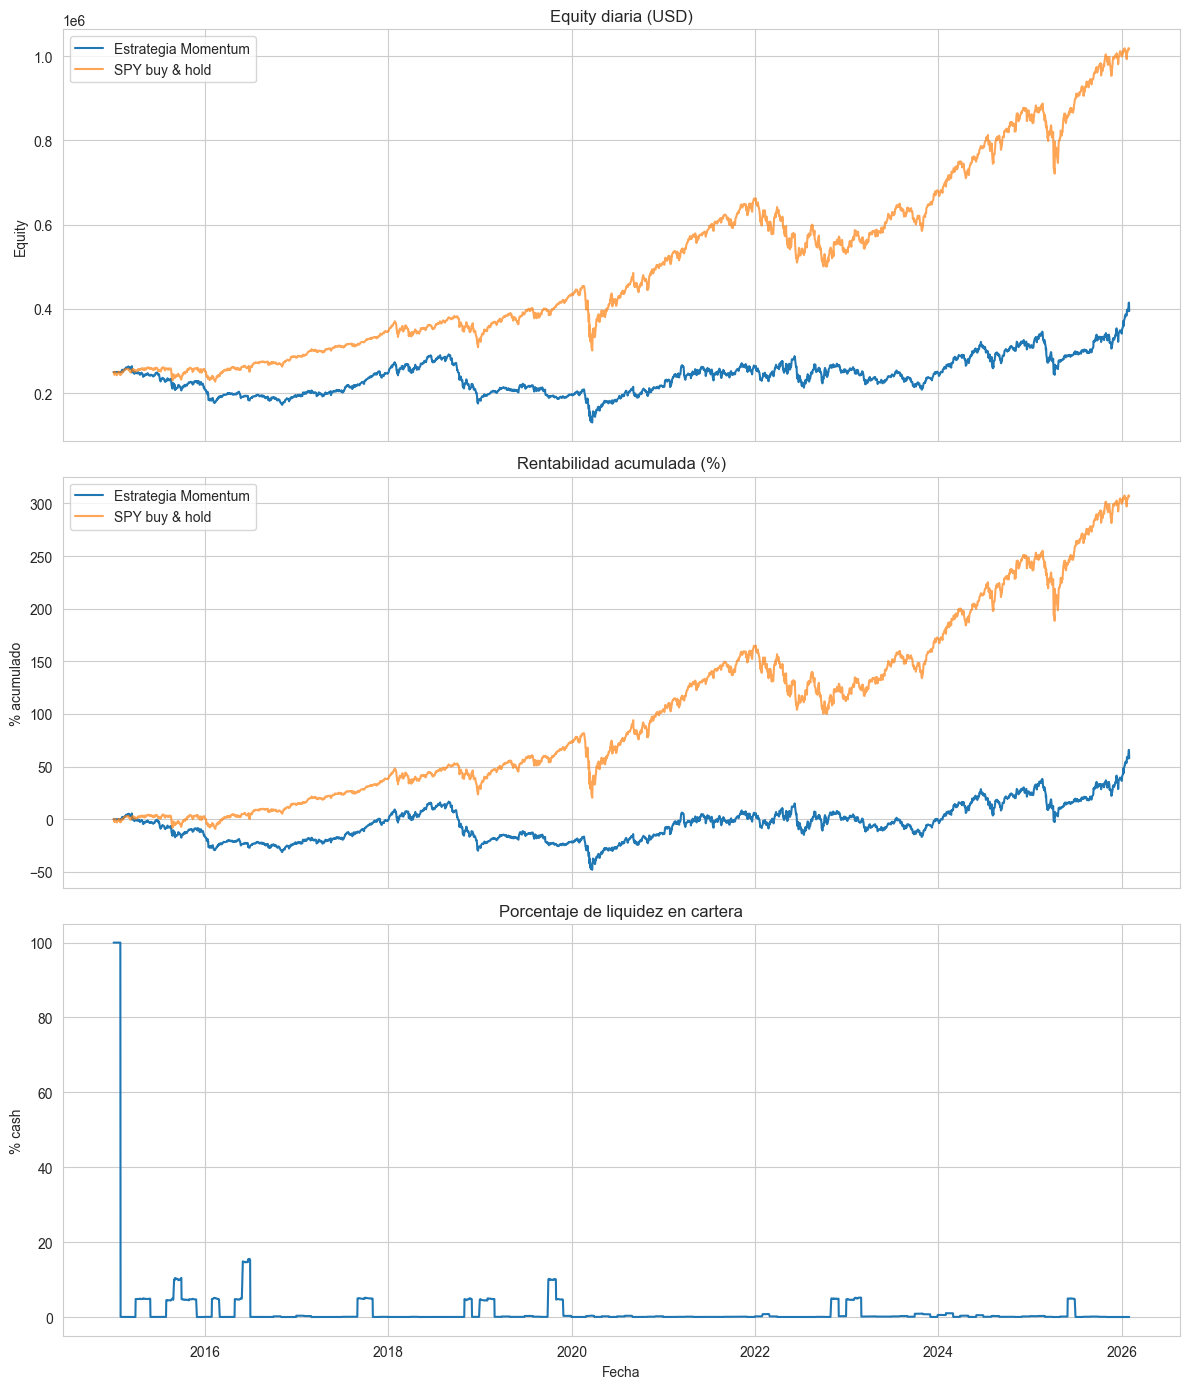

In [62]:
# Visualización de resultados

# Asegurar que tenemos los DataFrames en memoria (si se ejecuta este bloque solo)
if 'portfolio_df' == None or 'benchmark_df' == None:
    portfolio_df = pd.read_csv(OUTPUTS_DIR / 'portfolio_daily_equity.csv', parse_dates=['date']).set_index('date')
    benchmark_df = pd.read_csv(OUTPUTS_DIR / 'benchmark_daily_equity.csv', parse_dates=['date']).set_index('date')

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# 1) Curvas de equity absolutas
axes[0].plot(portfolio_df.index, portfolio_df['equity'], label='Estrategia Momentum')
axes[0].plot(benchmark_df.index, benchmark_df['spy_equity'], label='SPY buy & hold', alpha=0.7)
axes[0].set_title('Equity diaria (USD)')
axes[0].set_ylabel('Equity')
axes[0].legend()

# 2) Rentabilidad acumulada (%)
ret_algo = portfolio_df['equity'] / INITIAL_CAPITAL - 1.0
ret_spy = benchmark_df['spy_equity'] / INITIAL_CAPITAL - 1.0

axes[1].plot(ret_algo.index, 100 * ret_algo, label='Estrategia Momentum')
axes[1].plot(ret_spy.index, 100 * ret_spy, label='SPY buy & hold', alpha=0.7)
axes[1].set_title('Rentabilidad acumulada (%)')
axes[1].set_ylabel('% acumulado')
axes[1].legend()

# 3) Porcentaje de liquidez
cash_pct = portfolio_df['cash'] / portfolio_df['equity']
axes[2].plot(cash_pct.index, 100 * cash_pct)
axes[2].set_title('Porcentaje de liquidez en cartera')
axes[2].set_ylabel('% cash')
axes[2].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

> <u>Comentario</u>: Las tres gráficas permiten comparar la estrategia Momentum con el benchmark SPY y el uso de liquidez.
>
> - <u>Equity diaria (USD)</u>: Ambas series parten del mismo capital inicial y muestran trayectorias distintas durante el backtest. La lectura correcta debe hacerse con los valores finales y los CAGR impresos en esta ejecución (apartado **8.2**), ya que pueden cambiar al actualizar datos o rehacer el pipeline.
>
> - <u>Rentabilidad acumulada (%)</u>: La comparación visual de retornos acumulados resume la diferencia de desempeño entre estrategia y benchmark en el periodo analizado. Para evitar inconsistencias, la interpretación cuantitativa se apoya en las cifras dinámicas de la tabla de métricas del Notebook 5 y en los outputs calculados en tiempo de ejecución.
>
> - <u>Porcentaje de liquidez en cartera</u>: Al inicio hay 100 % cash hasta el primer rebalanceo; después, la liquidez suele bajar y permanecer contenida, con variaciones por redondeo a acciones enteras, comisiones y disponibilidad de precios en los activos seleccionados. Al final del backtest se mantienen posiciones (sin liquidación total a cash).

### <font color=#336699>**8.2. Análisis de liquidez**</font>

Para profundizar en la serie de `% cash`, se añaden tres vistas complementarias:

1. **Detección de picos relevantes de liquidez** (excluyendo el 100 % inicial antes del primer rebalanceo).
2. **Tabla de eventos** con contexto operativo en torno a cada pico (nº de operaciones, compras/ventas y drawdown local de equity).
3. **Zoom específico** sobre 2016 (o, si no aplica, sobre el pico más alto) para inspeccionar su dinámica temporal.

Este bloque ayuda a separar picos estructurales (rebalanceo, fricciones por comisiones/redondeo) de episodios puntuales de mercado.

Umbral de pico aplicado: 5.00% cash
Picos detectados (top eventos no solapados):


,fecha_pico,cash_pct,equity_usd,drawdown_local_30d,ops_ventana_30d,compras_ventana_30d,ventas_ventana_30d
0,2015-01-29,100.00%,"$250,000",-1.71%,20,20,0
3,2016-06-27,15.53%,"$182,375",-5.80%,23,9,14
1,2015-09-29,10.46%,"$206,225",-6.04%,22,7,15
6,2019-10-02,10.20%,"$188,387",-9.49%,27,11,16
7,2023-02-22,5.22%,"$241,574",-6.62%,27,13,14
4,2017-10-02,5.15%,"$229,318",-2.15%,22,13,9
2,2016-02-08,5.11%,"$176,561",-6.27%,26,13,13
5,2018-11-20,5.00%,"$208,464",-10.32%,30,14,16


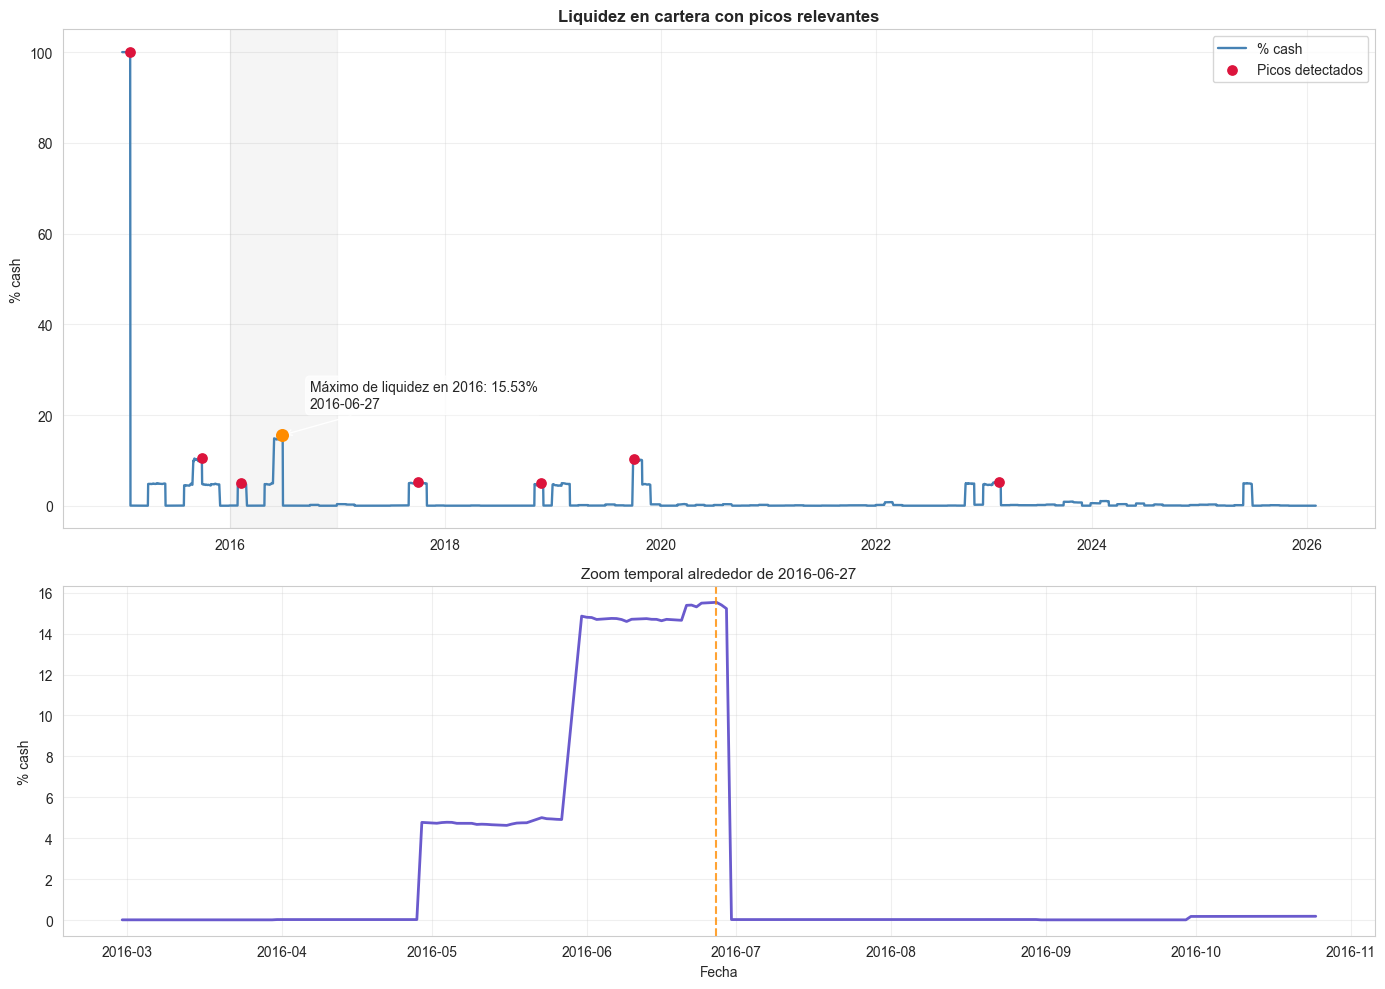

In [63]:
# Análisis detallado de liquidez (% cash)
cash_pct = (100.0 * portfolio_df['cash'] / portfolio_df['equity']).replace([np.inf, -np.inf], np.nan).dropna().sort_index()

# Para detectar picos operativos, excluimos el primer tramo (100 % cash antes del primer rebalanceo).
cash_for_peaks = cash_pct.iloc[1:] if len(cash_pct) > 1 else cash_pct.copy()

if cash_for_peaks.empty:
    print('No hay datos suficientes para analizar picos de liquidez.')
else:
    peak_threshold = max(5.0, float(cash_for_peaks.quantile(0.90)))
    is_local_peak = (
        (cash_for_peaks >= cash_for_peaks.shift(1))
        & (cash_for_peaks > cash_for_peaks.shift(-1))
        & (cash_for_peaks >= peak_threshold)
    )
    peak_candidates = cash_for_peaks[is_local_peak].sort_values(ascending=False)

    # Compactar picos cercanos para evitar duplicar el mismo episodio.
    selected_peaks = []
    min_separation_days = 35
    for dt, _ in peak_candidates.items():
        if all(abs((dt - prev).days) > min_separation_days for prev in selected_peaks):
            selected_peaks.append(dt)
        if len(selected_peaks) >= 8:
            break

    if not selected_peaks:
        selected_peaks = cash_for_peaks.nlargest(min(5, len(cash_for_peaks))).index.tolist()

    selected_peaks = sorted(selected_peaks)

    # Cargar trades si no están en memoria (útil al ejecutar solo esta sección).
    if 'trades_df' not in globals():
        try:
            trades_df = pd.read_csv(OUTPUTS_DIR / 'trades_detail.csv', parse_dates=['date'])
        except Exception:
            trades_df = pd.DataFrame()

    trades_aux = trades_df.copy() if 'trades_df' in globals() and not trades_df.empty else pd.DataFrame()
    if not trades_aux.empty:
        trades_aux['date'] = pd.to_datetime(trades_aux['date'])

    rows = []
    for dt in selected_peaks:
        liquidity = float(cash_pct.loc[dt])
        equity_usd = float(portfolio_df.loc[dt, 'equity'])

        win_start = dt - pd.Timedelta(days=15)
        win_end = dt + pd.Timedelta(days=15)

        eq_win = portfolio_df.loc[win_start:win_end, 'equity']
        local_dd = float((eq_win / eq_win.cummax() - 1.0).min()) if not eq_win.empty else np.nan

        if not trades_aux.empty:
            ops_win = trades_aux[(trades_aux['date'] >= win_start) & (trades_aux['date'] <= win_end)]
            n_ops = int(len(ops_win))
            n_buys = int((ops_win['side'].astype(str).str.startswith('BUY')).sum())
            n_sells = int((ops_win['side'].astype(str).str.startswith('SELL')).sum())
        else:
            n_ops, n_buys, n_sells = np.nan, np.nan, np.nan

        rows.append({
            'fecha_pico': dt,
            'cash_pct': liquidity,
            'equity_usd': equity_usd,
            'drawdown_local_30d': local_dd,
            'ops_ventana_30d': n_ops,
            'compras_ventana_30d': n_buys,
            'ventas_ventana_30d': n_sells,
        })

    liquidity_events = pd.DataFrame(rows).sort_values('cash_pct', ascending=False)

    print(f'Umbral de pico aplicado: {peak_threshold:.2f}% cash')
    print('Picos detectados (top eventos no solapados):')

    liquidity_events_display = liquidity_events.copy()
    liquidity_events_display['cash_pct'] = liquidity_events_display['cash_pct'].map(lambda x: f'{x:.2f}%')
    liquidity_events_display['equity_usd'] = liquidity_events_display['equity_usd'].map(lambda x: f'${x:,.0f}')
    liquidity_events_display['drawdown_local_30d'] = liquidity_events_display['drawdown_local_30d'].map(
        lambda x: f'{x:.2%}' if pd.notna(x) else 'NaN'
    )
    display(liquidity_events_display)

    # ---- Visualización: serie completa + zoom en 2016 (o pico global) ----
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1.4]})

    axes[0].plot(cash_pct.index, cash_pct.values, color='steelblue', linewidth=1.7, label='% cash')
    axes[0].scatter(selected_peaks, cash_pct.loc[selected_peaks], color='crimson', s=45, zorder=3, label='Picos detectados')
    axes[0].set_title('Liquidez en cartera con picos relevantes', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('% cash')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper right')

    cash_2016 = cash_pct[cash_pct.index.year == 2016]
    if not cash_2016.empty:
        focus_date = cash_2016.idxmax()
        focus_label = 'Máximo de liquidez en 2016'
        axes[0].axvspan(pd.Timestamp('2016-01-01'), pd.Timestamp('2016-12-31'), color='gray', alpha=0.08)
    else:
        focus_date = cash_for_peaks.idxmax()
        focus_label = 'Máximo global de liquidez'

    focus_value = float(cash_pct.loc[focus_date])
    axes[0].scatter([focus_date], [focus_value], color='darkorange', s=70, zorder=4)
    axes[0].annotate(
        f'{focus_label}: {focus_value:.2f}%\n{focus_date:%Y-%m-%d}',
        xy=(focus_date, focus_value),
        xytext=(20, 20),
        textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
        arrowprops=dict(arrowstyle='->', lw=1.0)
    )

    zoom_start = focus_date - pd.Timedelta(days=120)
    zoom_end = focus_date + pd.Timedelta(days=120)
    zoom_cash = cash_pct.loc[zoom_start:zoom_end]

    axes[1].plot(zoom_cash.index, zoom_cash.values, color='slateblue', linewidth=2)
    axes[1].axvline(focus_date, color='darkorange', linestyle='--', alpha=0.8)
    axes[1].set_title(f'Zoom temporal alrededor de {focus_date:%Y-%m-%d}', fontsize=11)
    axes[1].set_xlabel('Fecha')
    axes[1].set_ylabel('% cash')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

> <u>Interpretación de resultados (esta ejecución)</u>:
>
> - El pico de 100 % cash (2015-01-29) corresponde al arranque del backtest, cuando el capital aún no está desplegado. Es un efecto inicial de la simulación y no un episodio de mercado.
> - El evento principal es 2016-06-27 (15.53 %). En esa ventana hay más ventas (14) que compras (9) y drawdown local de -5.80 %, señal de fricción en la recomposición de la cartera durante el rebalanceo.
> - En otros picos (2015-09, 2019-10, 2023-02 y 2018-11) también predomina, o al menos se iguala, el flujo vendedor frente al comprador. El patrón encaja con la mecánica del ejercicio: venta al open, compra al close, comisiones y redondeo a acciones enteras.
> - El rango de drawdown local observado (aprox. -2 % a -10 %) sugiere que estos repuntes de liquidez aparecen con más frecuencia en fases de mayor tensión o rotación del universo, donde no siempre se logra reinvertir todo el efectivo en el mismo día.
> - Con umbral de 5 %, parte de los picos son moderados, pero en conjunto la serie muestra una cartera normalmente invertida y aumentos puntuales de caja asociados al proceso operativo definido en la práctica.
>
> Como cierre del análisis, conviene cruzar cada pico con retorno posterior y métricas de riesgo del Notebook 5 para medir si la liquidez transitoria penaliza rentabilidad, reduce drawdown o ambas cosas.

### <font color=#336699>**8.3. Evolución del capital (USD)**</font>

Gráfico único de la evolución del valor de la cartera y del SPY en dólares, con CAGR en leyenda, línea de capital inicial y resumen de valores finales en consola.

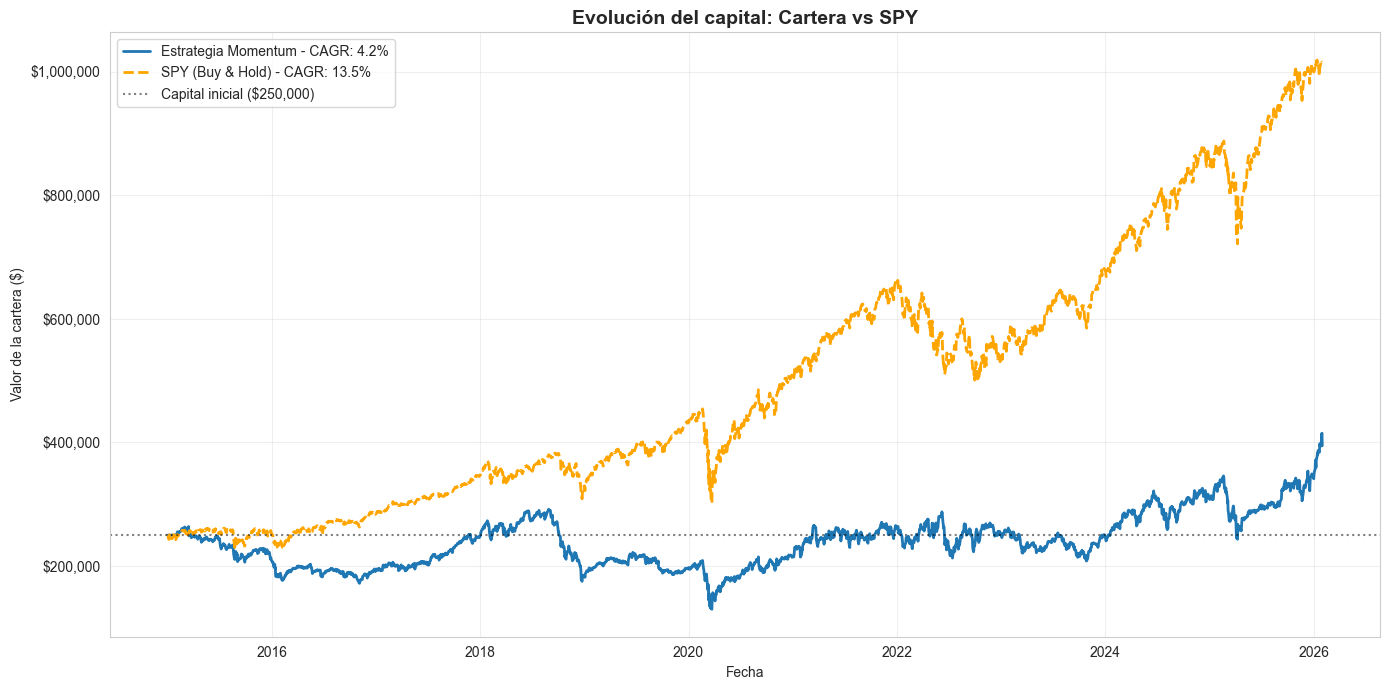


Valor final de la cartera: $395,006.84
Valor final del benchmark: $1,017,119.42
Diferencia: $-622,112.58


In [64]:
# Evolución del capital (USD): cartera vs SPY con CAGR en leyenda
common_idx = portfolio_df.index.intersection(benchmark_df.index)
equity_algo = portfolio_df.loc[common_idx, 'equity'].squeeze()
equity_spy = benchmark_df.loc[common_idx, 'spy_equity'].squeeze()

years = (common_idx[-1] - common_idx[0]).days / 365.25
cagr_algo = (equity_algo.iloc[-1] / equity_algo.iloc[0]) ** (1 / years) - 1
cagr_spy = (equity_spy.iloc[-1] / equity_spy.iloc[0]) ** (1 / years) - 1

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(common_idx, equity_algo, label=f'Estrategia Momentum - CAGR: {cagr_algo:.1%}', linewidth=2)
ax.plot(common_idx, equity_spy, label=f'SPY (Buy & Hold) - CAGR: {cagr_spy:.1%}', linewidth=2, color='orange', linestyle='--')
ax.axhline(y=INITIAL_CAPITAL, color='black', linestyle=':', alpha=0.5, label=f'Capital inicial (${INITIAL_CAPITAL:,.0f})')
ax.set_title('Evolución del capital: Cartera vs SPY', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor de la cartera ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print(f"\nValor final de la cartera: ${equity_algo.iloc[-1]:,.2f}")
print(f"Valor final del benchmark: ${equity_spy.iloc[-1]:,.2f}")
print(f"Diferencia: ${equity_algo.iloc[-1] - equity_spy.iloc[-1]:,.2f}")


> <u>Comentario</u>:
>
> El gráfico muestra que, la estrategia Momentum queda claramente por detrás del benchmark SPY (buy & hold).
>
> Con un capital inicial de 250,000$, la cartera termina en 395,006.84$, mientras que el benchmark alcanza 1,017,119.42$; esto deja una diferencia de -622,112.58$ a favor de SPY. Aunque la estrategia incrementa el capital en términos absolutos, su crecimiento compuesto es sustancialmente inferior al del benchmark. 
>
>La lectura final debe apoyarse en las métricas del Notebook 5 (Sharpe, drawdown, alpha y Monte Carlo) para evaluar si este menor retorno se compensa con un perfil de riesgo más defensivo.